## LARIAC temporal symdiff — 2014→2017→2020

Per-AIN geometric difference across epochs. For each neighborhood × epoch pair:
load raw LARIAC → split thin connections → dissolve to AIN footprint → align epochs (region-wide mean shift) → compute added/removed geometry → classify change type.

**Output**: `data/04_results/lariac_symdiff.gpkg`

In [1]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
from shapely.affinity import translate

os.chdir('../..')
print(f"Working directory: {os.getcwd()}")

UTM_CRS          = 32611   # UTM Zone 11N, metres — used for all geometry ops
NECK_THRESHOLD_M = 1.0     # erode by 1 m → severs necks narrower than ~2 m
MASTER           = "data/processed/assessor_lariac.gpkg"

from src.geoadmin import load_neighborhoods, load_cities, load_laraic

cities = load_cities().to_crs(4326)
hoods  = load_neighborhoods()
lacity = cities.query('CITYNAME_ALF == "LOS ANGELES"')

lacity_hood_names = set(
    gpd.sjoin(
        hoods.set_geometry(hoods.centroid.to_crs(4326)).set_crs(4326),
        lacity[['geometry']],
        predicate='intersects'
    )['name'].tolist()
)
print(f"{len(lacity_hood_names)} LA City neighborhoods")

Working directory: /Users/adamswietek/Documents/PostDoc/HiddenHousing
122 LA City neighborhoods


/var/folders/7b/rl6lkdns1dbfv_n3wwwmq8580000gn/T/ipykernel_74694/492099452.py:23: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  hoods.set_geometry(hoods.centroid.to_crs(4326)).set_crs(4326),


In [2]:
# ── params ────────────────────────────────────────────────────────────────────
STORE_SYMDIFF    = True   # True → also write added/removed geometry layers; False for production
SLIVER_BUFFER_M  = 0.4     # metres — border band width for sliver suppression

TEST_HOODS  = list(lacity_hood_names)#[:2]# for testing
EPOCH_PAIRS = [(2014, 2017), (2017, 2020)]

OUTPUT_PATH = "data/04_results/lariac_symdiff.gpkg"

### Helper functions

In [3]:
def split_thin_connections(gdf: gpd.GeoDataFrame,
                           threshold: float = NECK_THRESHOLD_M) -> gpd.GeoDataFrame:
    """Erode-dilate in UTM metres to sever thin connections.
    join_style=2 (mitre) preserves sharp corners on rectangular building footprints.
    """
    orig_crs = gdf.crs
    gdf_utm  = gdf.to_crs(UTM_CRS)
    min_area = 3.14159 * threshold ** 2
    rows = []
    for _, row in gdf_utm.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        eroded = geom.buffer(-threshold, join_style=2)
        if eroded.is_empty:
            rows.append(row)
            continue
        restored = eroded.buffer(threshold, join_style=2)
        if restored.geom_type == 'MultiPolygon':
            for part in restored.geoms:
                if part.area >= min_area:
                    r = row.copy(); r.geometry = part; rows.append(r)
        else:
            r = row.copy(); r.geometry = restored; rows.append(r)
    return gpd.GeoDataFrame(rows, crs=UTM_CRS).reset_index(drop=True).to_crs(orig_crs)


def assign_ain_and_dissolve(lar: gpd.GeoDataFrame,
                            parcel_ref: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Dissolve split LARIAC buildings to AIN-level footprint union.
    Uses LARIAC's own AIN field where available; falls back to centroid spatial join.
    Returns GDF indexed by AIN with: footprint (parcel_ref CRS), geom_area (m²), n_buildings.
    """
    lar = lar.to_crs(parcel_ref.crs).copy()
    if 'AIN' in lar.columns and lar['AIN'].notna().any():
        lar['AIN'] = lar['AIN'].astype(str)
    else:
        centroids = lar.set_geometry(lar.centroid)
        joined    = gpd.sjoin(centroids, parcel_ref[['AIN', 'geometry']], how='left')
        lar['AIN'] = joined['AIN'].values

    n_bldgs   = lar.groupby('AIN').size().rename('n_buildings')
    dissolved = lar.dissolve(by='AIN')[['geometry']].rename_geometry('footprint')
    dissolved['geom_area']   = dissolved['footprint'].to_crs(UTM_CRS).area  # m²
    dissolved['n_buildings'] = n_bldgs
    return dissolved


def estimate_region_shift(d1: gpd.GeoDataFrame,
                          d2: gpd.GeoDataFrame) -> tuple[float, float]:
    """Mean centroid displacement (UTM metres) across ALL AINs common to both epochs.
    Uses the full region for a robust estimate — no first-pass classification needed.
    """
    common = d1.index.intersection(d2.index)
    if len(common) < 5:
        return 0.0, 0.0
    c1 = d1.loc[common, 'footprint'].to_crs(UTM_CRS).centroid
    c2 = d2.loc[common, 'footprint'].to_crs(UTM_CRS).centroid
    dx = float((c2.x.values - c1.x.values).mean())
    dy = float((c2.y.values - c1.y.values).mean())
    return dx, dy


def apply_shift(dissolved: gpd.GeoDataFrame, dx: float, dy: float) -> gpd.GeoDataFrame:
    """Translate footprints by (-dx, -dy) metres in UTM to align with t1 reference frame."""
    if abs(dx) < 0.01 and abs(dy) < 0.01:
        return dissolved
    orig_crs  = dissolved.crs
    corrected = dissolved.copy()
    corrected['footprint'] = (
        dissolved['footprint']
        .to_crs(UTM_CRS)
        .apply(lambda g: translate(g, xoff=-dx, yoff=-dy))
        .set_crs(UTM_CRS)
        .to_crs(orig_crs)
    )
    corrected['geom_area'] = corrected['footprint'].to_crs(UTM_CRS).area
    return corrected

In [4]:
def filter_slivers(added, removed):
    """Remove thin sliver artifacts from symdiff geometry via morphological opening.

    Slivers arise from sub-pixel epoch misalignment and are not expected to represent
    real housing additions.  Erode by SLIVER_BUFFER_M then re-dilate: anything thinner
    than ~2 × SLIVER_BUFFER_M disappears; the bulk of real additions is restored intact.
    """
    def opening(geom):
        if geom is None or geom.is_empty:
            return geom
        return geom.buffer(-SLIVER_BUFFER_M).buffer(SLIVER_BUFFER_M)

    return opening(added), opening(removed)

In [5]:
def process_hood_epoch(hood: str, yr1: int, yr2: int,
                       parcel_ref: gpd.GeoDataFrame,
                       store_geoms: bool = False) -> dict:
    """Full pipeline for one neighborhood × epoch pair.

    Returns dict with:
      'metrics'    — GDF: one row per AIN, parcel geometry, scalar metrics
      'added'      — GDF: cleaned added footprint geometries    (only if store_geoms=True)
      'removed'    — GDF: cleaned removed footprint geometries  (only if store_geoms=True)
      'footprints' — {yr1: dissolved_gdf, yr2: dissolved_gdf}  (only if store_geoms=True)
    """
    aoi = hoods[hoods['name'] == hood]

    # 1. load, filter to buildings, split thin connections
    raw = {}
    for yr in (yr1, yr2):
        lar = load_laraic(aoi, yr)
        lar = lar[lar['CODE'] == 'Building'].copy().to_crs(parcel_ref.crs)
        raw[yr] = split_thin_connections(lar)

    # 2. dissolve to AIN-level footprint union
    d = {yr: assign_ain_and_dissolve(raw[yr], parcel_ref) for yr in (yr1, yr2)}

    # 3. region-wide epoch alignment — mean shift over ALL common AINs (UTM metres)
    dx, dy = estimate_region_shift(d[yr1], d[yr2])
    d[yr2] = apply_shift(d[yr2], dx, dy)

    # 4. per-AIN symdiff in UTM → sliver filter → clean area metrics
    fp1_utm = d[yr1]['footprint'].to_crs(UTM_CRS)
    fp2_utm = d[yr2]['footprint'].to_crs(UTM_CRS)

    all_ains = d[yr1].index.union(d[yr2].index)
    metric_rows   = []
    symdiff_cache = {}   # AIN → {'added': Shapely|None, 'removed': Shapely|None}  (UTM)

    for ain in all_ains:
        has1 = ain in d[yr1].index
        has2 = ain in d[yr2].index
        a1   = float(d[yr1].loc[ain, 'geom_area'])    if has1 else 0.0
        a2   = float(d[yr2].loc[ain, 'geom_area'])    if has2 else 0.0
        n1   = int(d[yr1].loc[ain, 'n_buildings'])    if has1 else 0
        n2   = int(d[yr2].loc[ain, 'n_buildings'])    if has2 else 0

        if has1 and has2:
            g1 = fp1_utm.loc[ain]
            g2 = fp2_utm.loc[ain]
            raw_added   = g2.difference(g1)
            raw_removed = g1.difference(g2)
            added_clean, removed_clean = filter_slivers(raw_added, raw_removed)
            area_clean_added   = added_clean.area   if (added_clean   and not added_clean.is_empty)   else 0.0
            area_clean_removed = removed_clean.area if (removed_clean and not removed_clean.is_empty) else 0.0
            area_net = area_clean_added - area_clean_removed
        elif has2:          # new parcel — full t2 footprint is "added"
            added_clean, removed_clean = fp2_utm.loc[ain], None
            area_net = a2
        else:               # demolished — full t1 footprint is "removed"
            added_clean, removed_clean = None, fp1_utm.loc[ain]
            area_net = -a1

        symdiff_cache[ain] = {'added': added_clean, 'removed': removed_clean}
        metric_rows.append({
            'AIN':           ain,
            f'area_{yr1}':   a1,
            f'area_{yr2}':   a2,
            f'n_{yr1}':      n1,
            f'n_{yr2}':      n2,
            'area_net':      area_net,
            'n_delta':       n2 - n1,
        })

    m = pd.DataFrame(metric_rows).set_index('AIN')
    m['epoch']        = f'{yr1}→{yr2}'
    m['neighborhood'] = hood
    m['shift_dx_m']   = round(dx, 3)
    m['shift_dy_m']   = round(dy, 3)

    # 5. classify  (area_net is now sliver-filtered)
    def classify(row):
        n1, n2 = row[f'n_{yr1}'], row[f'n_{yr2}']
        da, dn = row['area_net'], row['n_delta']
        if n1 == 0 and n2 > 0:  return 'new_parcel'
        if n2 == 0 and n1 > 0:  return 'demolished'
        if dn > 0  and da > 0:  return 'added_structure'
        if dn < 0  and da < 0:  return 'removed_structure'
        if dn == 0 and da >  2: return 'extended'
        if dn == 0 and da < -2: return 'reduced'
        return 'no_change'

    m['change_type'] = m.apply(classify, axis=1)

    # 6. attach parcel boundary geometry
    m = m.join(parcel_ref.set_index('AIN')['geometry'], how='left')
    metrics_gdf = gpd.GeoDataFrame(m, geometry='geometry', crs=parcel_ref.crs)
    metrics_gdf.index.name = 'AIN'
    out = {'metrics': metrics_gdf.reset_index()}

    # 7. store cleaned symdiff geometries + dissolved footprints (optional)
    if store_geoms:
        out['footprints'] = {yr1: d[yr1], yr2: d[yr2]}

        added_rows, removed_rows = [], []
        for ain, geoms in symdiff_cache.items():
            base = {'AIN': ain, 'neighborhood': hood, 'epoch': f'{yr1}→{yr2}'}
            ag, rg = geoms['added'], geoms['removed']
            if ag is not None and not ag.is_empty:
                ag_proj = gpd.GeoSeries([ag], crs=UTM_CRS).to_crs(parcel_ref.crs).iloc[0]
                added_rows.append({**base, 'geometry': ag_proj})
            if rg is not None and not rg.is_empty:
                rg_proj = gpd.GeoSeries([rg], crs=UTM_CRS).to_crs(parcel_ref.crs).iloc[0]
                removed_rows.append({**base, 'geometry': rg_proj})

        if added_rows:
            out['added']   = gpd.GeoDataFrame(added_rows,   crs=parcel_ref.crs)
        if removed_rows:
            out['removed'] = gpd.GeoDataFrame(removed_rows, crs=parcel_ref.crs)

    return out

### Parcel reference

In [6]:
# Load parcel geometries from master (2017 layer — stable mid-period reference)
parcel_ref = (
    gpd.read_file(MASTER, layer='2017')[['AIN', 'geometry']]
    .assign(AIN=lambda d: d['AIN'].astype(str))
    .dropna(subset=['geometry'])
    .drop_duplicates('AIN')
    .reset_index(drop=True)
)
print(f"Parcel ref: {len(parcel_ref):,} parcels  CRS: {parcel_ref.crs}")

Parcel ref: 685,401 parcels  CRS: EPSG:2229


### Run

In [7]:
import os
os.environ['CPL_LOG_ERRORS'] = 'OFF'


In [8]:
from tqdm import tqdm

results_metrics  = []
results_added    = []
results_removed  = []
footprints_cache = {}   # (hood, yr) → dissolved GDF, keyed for QC lookup

for hood in tqdm(TEST_HOODS, desc='Neighborhoods'):
    for yr1, yr2 in EPOCH_PAIRS:
        try:
            out = process_hood_epoch(hood, yr1, yr2, parcel_ref,
                                     store_geoms=STORE_SYMDIFF)
            results_metrics.append(out['metrics'])
            if STORE_SYMDIFF:
                if 'added'      in out: results_added.append(out['added'])
                if 'removed'    in out: results_removed.append(out['removed'])
                if 'footprints' in out:
                    for yr, fp_gdf in out['footprints'].items():
                        footprints_cache[(hood, yr)] = fp_gdf
        except Exception as e:
            print(f"  {hood} {yr1}→{yr2}: ERROR — {e}")

all_metrics = pd.concat(results_metrics, ignore_index=True)
print(all_metrics.groupby(['epoch', 'change_type']).size().unstack(fill_value=0))

Neighborhoods:   0%|          | 0/122 [00:00<?, ?it/s]

ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(path_or_bytes, layer=kwargs.get("layer")).get("crs")
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (defa

  Winnetka 2017→2020: ERROR — TopologyException: side location conflict at 354617.96606573928 3785683.4015213894. This can occur if the input geometry is invalid.


ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(path_or_bytes, layer=kwargs.get("layer")).get("crs")
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (defa

  Boyle Heights 2014→2017: ERROR — TopologyException: side location conflict at 388304.7697113445 3767032.490470523. This can occur if the input geometry is invalid.


...

  Woodland Hills 2014→2017: ERROR — TopologyException: side location conflict at 350916.47679639538 3782510.8254526611. This can occur if the input geometry is invalid.


ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/core.py:280: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read_info(
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC5_Buildings_2017.gdb': 'LARIAC5_BUILDINGS_2017' (default), 'LARIAC4_BUILDINGS_DELETED_2017'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(pa

  Woodland Hills 2017→2020: ERROR — TopologyException: side location conflict at 350873.61266912991 3782510.7960549174. This can occur if the input geometry is invalid.


ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(path_or_bytes, layer=kwargs.get("layer")).get("crs")
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (defa

change_type  added_structure  demolished  extended  new_parcel  no_change  \
epoch                                                                       
2014→2017               8700       41233     17107        6899     335829   
2017→2020               4685        2103     16648        1993     367412   

change_type  reduced  removed_structure  
epoch                                    
2014→2017       9631               7738  
2017→2020      12707               8032  


### Save

In [9]:
out_path = Path(OUTPUT_PATH)
out_path.parent.mkdir(parents=True, exist_ok=True)

for epoch_str, epoch_gdf in all_metrics.groupby('epoch'):
    layer = 'symdiff_' + epoch_str.replace('→', '_')
    epoch_gdf.to_file(out_path, driver='GPKG', layer=layer, mode='w')
    print(f"Saved {layer}: {len(epoch_gdf):,} rows")

if STORE_SYMDIFF:
    all_added   = pd.concat(results_added,   ignore_index=True) if results_added   else None
    all_removed = pd.concat(results_removed, ignore_index=True) if results_removed else None
    for tag, gdf in [('added', all_added), ('removed', all_removed)]:
        if gdf is not None and len(gdf):
            for epoch_str, sub in gdf.groupby('epoch'):
                layer = f'{tag}_{epoch_str.replace("→", "_")}'
                sub.to_file(out_path, driver='GPKG', layer=layer, mode='w')
                print(f"Saved {layer}: {len(sub):,} rows")

Saved symdiff_2014_2017: 427,137 rows
Saved symdiff_2017_2020: 413,580 rows
Saved added_2014_2017: 39,492 rows
Saved added_2017_2020: 30,573 rows
Saved removed_2014_2017: 66,783 rows
Saved removed_2017_2020: 32,285 rows


### QC visualization
One random example per change type. Only runs when `STORE_SYMDIFF=True`.

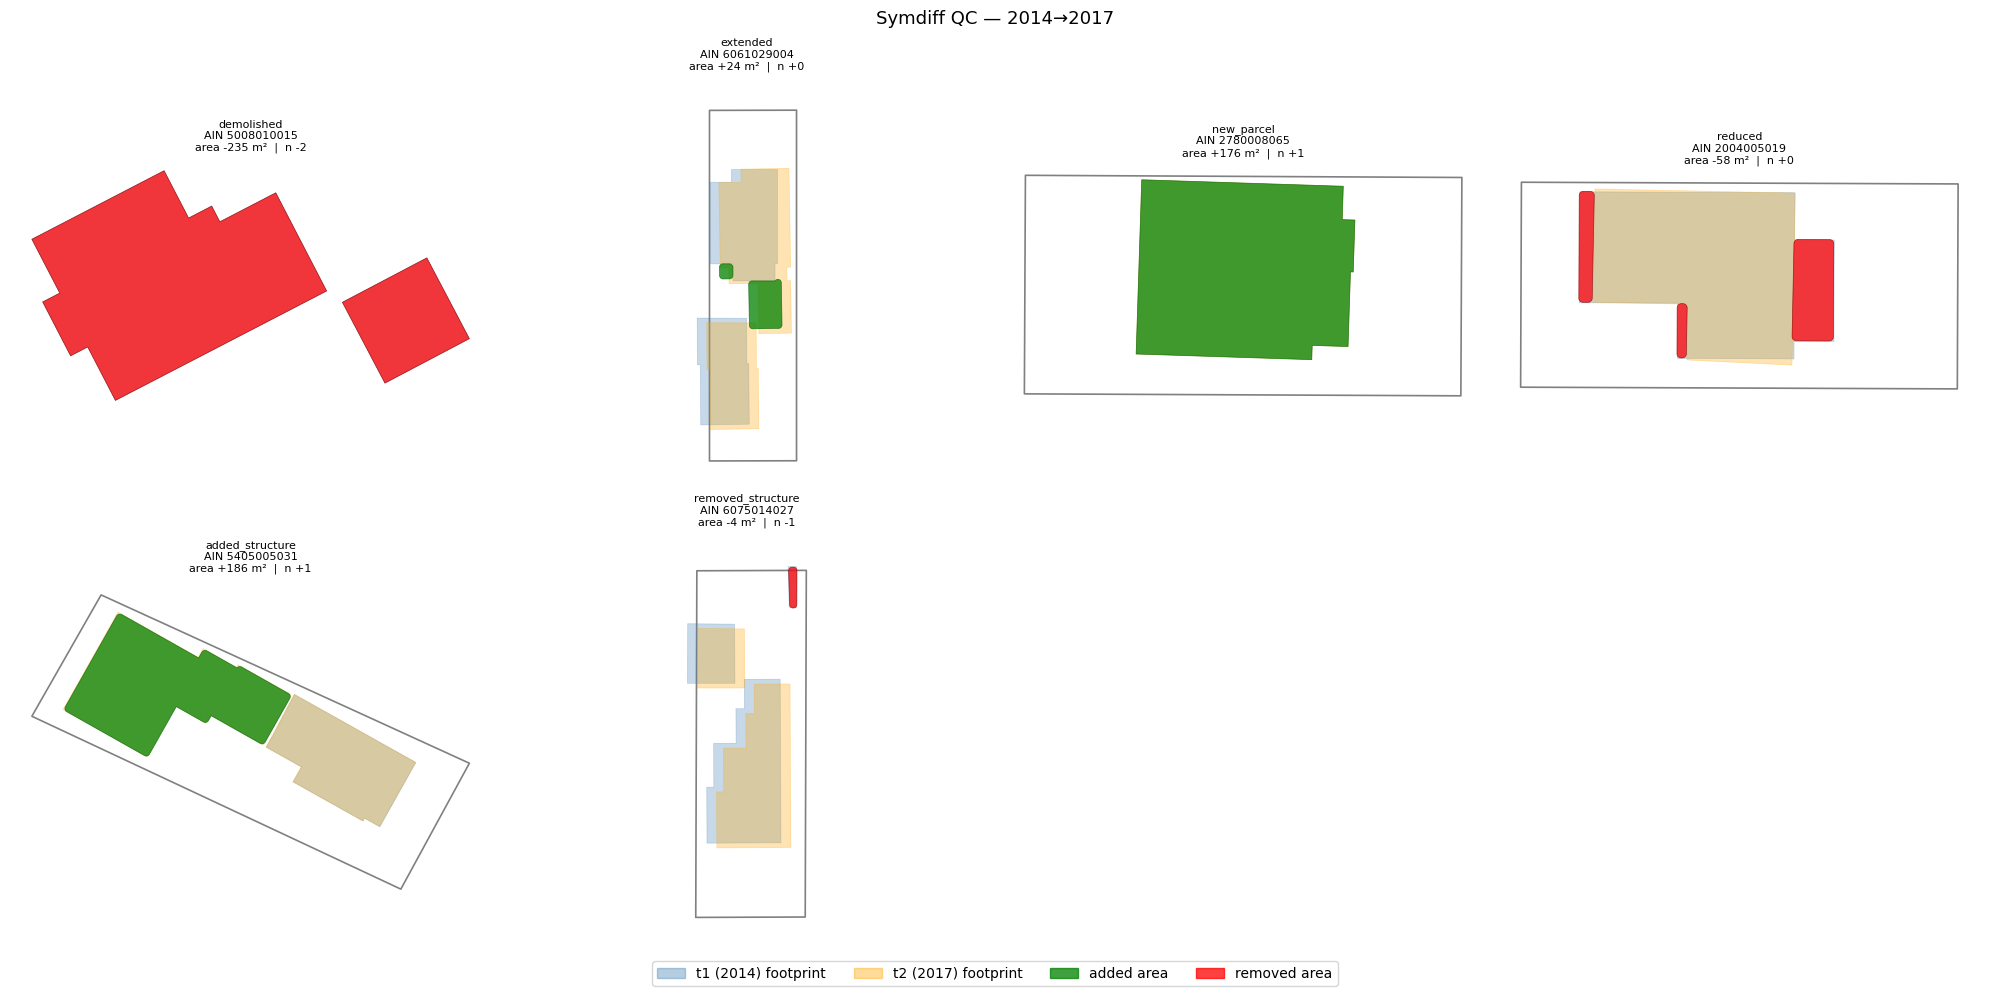

In [10]:
if not STORE_SYMDIFF:
    print("STORE_SYMDIFF=False — skipping QC plot")
else:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    # guard: footprints_cache is populated by the run cell; default to empty if missing
    if 'footprints_cache' not in dir():
        footprints_cache = {}

    yr1, yr2  = EPOCH_PAIRS[0]
    EPOCH_VIZ = f'{yr1}→{yr2}'

    # build fast AIN → geometry lookups
    added_lookup   = {}
    removed_lookup = {}
    if results_added:
        for _, r in pd.concat(results_added).iterrows():
            added_lookup[(r['AIN'], r['epoch'])] = r.geometry
    if results_removed:
        for _, r in pd.concat(results_removed).iterrows():
            removed_lookup[(r['AIN'], r['epoch'])] = r.geometry

    change_types = [ct for ct in all_metrics['change_type'].unique() if ct != 'no_change']
    n_cols = 4
    n_rows = -(-len(change_types) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    axes = axes.flatten()

    for ax, ct in zip(axes, change_types):
        cands = all_metrics[
            (all_metrics['epoch'] == EPOCH_VIZ) & (all_metrics['change_type'] == ct)
        ]
        if cands.empty:
            ax.set_title(f'{ct}\n(no examples)'); ax.axis('off'); continue

        row  = cands.sample(1, random_state=42).iloc[0]
        ain  = row['AIN']
        hood = row['neighborhood']

        # layer 1 — parcel boundary
        if row.geometry and not row.geometry.is_empty:
            gpd.GeoSeries([row.geometry], crs=all_metrics.crs).plot(
                ax=ax, facecolor='none', edgecolor='gray', linewidth=1.2)

        # layer 2 — LARIAC footprints t1 (blue) and t2 (orange)
        d1 = footprints_cache.get((hood, yr1))
        d2 = footprints_cache.get((hood, yr2))
        if d1 is not None and ain in d1.index:
            gpd.GeoSeries([d1.loc[ain, 'footprint']], crs=all_metrics.crs).plot(
                ax=ax, facecolor='steelblue', edgecolor='steelblue', alpha=0.3, linewidth=0.5)
        if d2 is not None and ain in d2.index:
            gpd.GeoSeries([d2.loc[ain, 'footprint']], crs=all_metrics.crs).plot(
                ax=ax, facecolor='orange', edgecolor='orange', alpha=0.3, linewidth=0.5)

        # layer 3 — symdiff: added (green) and removed (red)
        added_geom   = added_lookup.get((ain, EPOCH_VIZ))
        removed_geom = removed_lookup.get((ain, EPOCH_VIZ))
        if added_geom:
            gpd.GeoSeries([added_geom],   crs=all_metrics.crs).plot(
                ax=ax, color='green', alpha=0.75, edgecolor='darkgreen', linewidth=0.5)
        if removed_geom:
            gpd.GeoSeries([removed_geom], crs=all_metrics.crs).plot(
                ax=ax, color='red',   alpha=0.75, edgecolor='darkred',   linewidth=0.5)

        sign = lambda v: f'+{v:.0f}' if v >= 0 else f'{v:.0f}'
        ax.set_title(
            f'{ct}\nAIN {ain}\n'
            f'area {sign(row["area_net"])} m²  |  n {sign(row["n_delta"])}',
            fontsize=8
        )
        ax.axis('off')

    for ax in axes[len(change_types):]:
        ax.axis('off')

    patches = [
        mpatches.Patch(color='steelblue', alpha=0.4, label=f't1 ({yr1}) footprint'),
        mpatches.Patch(color='orange',    alpha=0.4, label=f't2 ({yr2}) footprint'),
        mpatches.Patch(color='green',     alpha=0.75, label='added area'),
        mpatches.Patch(color='red',       alpha=0.75, label='removed area'),
    ]
    fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=10)
    plt.suptitle(f'Symdiff QC — {EPOCH_VIZ}', fontsize=13)
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()

### Single-AIN filter debug

Runs the full pipeline for one AIN and exposes every intermediate geometry so the
sliver-filter effect can be inspected visually.

In [42]:
def debug_ain(ain: str, yr1: int, yr2: int,
              hood: str, parcel_ref: gpd.GeoDataFrame) -> dict:
    """Run the pipeline for a single AIN and return all intermediate geometries (UTM).

    Returns
    -------
    dict with keys:
      fp1, fp2          — dissolved building footprints in t1 / t2 (UTM)
      raw_added         — fp2 − fp1  before filtering
      raw_removed       — fp1 − fp2  before filtering
      clean_added       — surviving added area after morphological opening
      clean_removed     — surviving removed area after morphological opening
      filtered_added    — portion of raw_added that was suppressed
      filtered_removed  — portion of raw_removed that was suppressed
      parcel_geom       — assessor parcel boundary (UTM)
      dx, dy            — epoch alignment shift applied to t2 (metres)
    """
    aoi = hoods[hoods['name'] == hood]

    raw = {}
    for yr in (yr1, yr2):
        lar = load_laraic(aoi, yr)
        lar = lar[lar['CODE'] == 'Building'].copy().to_crs(parcel_ref.crs)
        raw[yr] = split_thin_connections(lar)

    d = {yr: assign_ain_and_dissolve(raw[yr], parcel_ref) for yr in (yr1, yr2)}

    dx, dy = estimate_region_shift(d[yr1], d[yr2])
    d[yr2] = apply_shift(d[yr2], dx, dy)

    fp1_utm = d[yr1]['footprint'].to_crs(UTM_CRS)
    fp2_utm = d[yr2]['footprint'].to_crs(UTM_CRS)

    if ain not in d[yr1].index or ain not in d[yr2].index:
        present = {yr: (ain in d[yr].index) for yr in (yr1, yr2)}
        raise ValueError(f"AIN {ain} missing in one or both epochs: {present}")

    g1 = fp1_utm.loc[ain]
    g2 = fp2_utm.loc[ain]

    raw_added   = g2.difference(g1)
    raw_removed = g1.difference(g2)
    clean_added, clean_removed = filter_slivers(raw_added, raw_removed)

    def safe_diff(a, b):
        if a is None or a.is_empty: return a
        return a.difference(b) if (b is not None and not b.is_empty) else a

    parcel_geom = (
        parcel_ref[parcel_ref['AIN'] == ain]
        .to_crs(UTM_CRS)
        .geometry.iloc[0]
    )

    return dict(
        fp1=g1, fp2=g2,
        raw_added=raw_added, raw_removed=raw_removed,
        clean_added=clean_added, clean_removed=clean_removed,
        filtered_added=safe_diff(raw_added, clean_added),
        filtered_removed=safe_diff(raw_removed, clean_removed),
        parcel_geom=parcel_geom, dx=dx, dy=dy,
    )

AIN: 4319013059  |  hood: Century City  |  area_net: 13.18 m²


ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(path_or_bytes, layer=kwargs.get("layer")).get("crs")
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (defa

Shift applied: dx=1.107 m  dy=-0.535 m


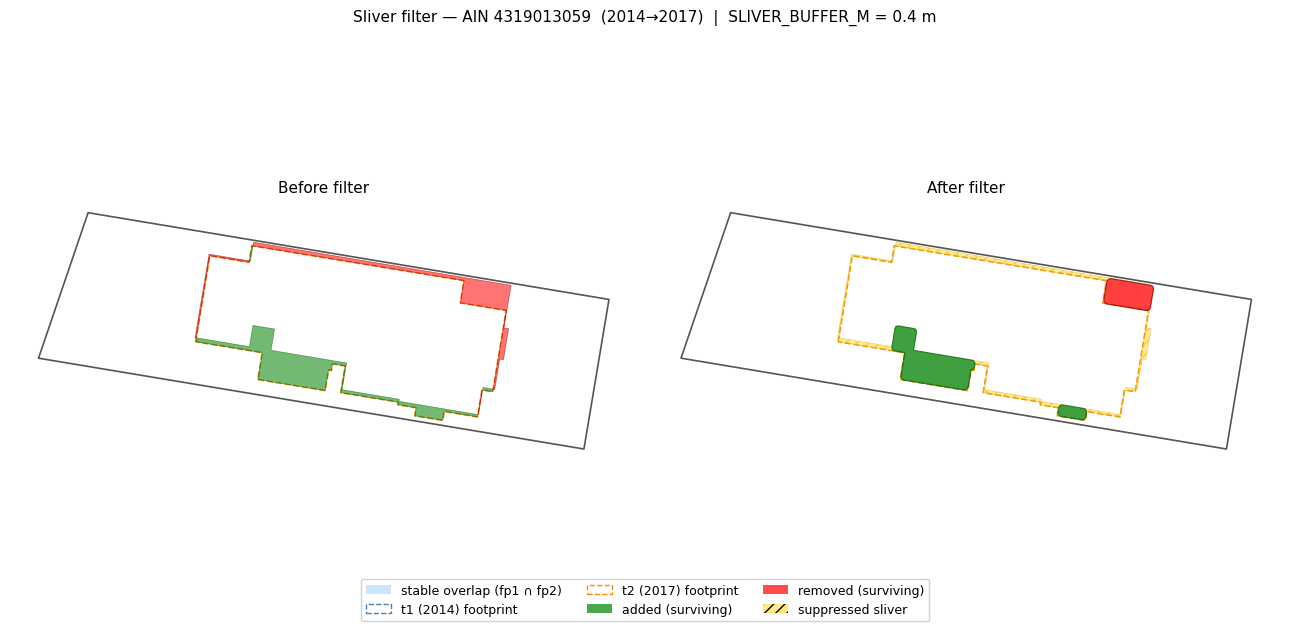

In [43]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── pick a test AIN ────────────────────────────────────────────────────────────
# Default: a random 'extended' case (most likely to carry alignment slivers).
# Override AIN / HOOD / EPOCH to inspect any parcel.
EPOCH  = (2014, 2017)
sample = (
    all_metrics[
        (all_metrics['epoch']       == f'{EPOCH[0]}→{EPOCH[1]}') &
        (all_metrics['change_type'] == 'extended')
    ]
    .sample(1, random_state=13)
    .iloc[0]
)
AIN  = sample['AIN']
HOOD = sample['neighborhood']
print(f"AIN: {AIN}  |  hood: {HOOD}  |  area_net: {sample['area_net']:.2f} m²")

g = debug_ain(AIN, *EPOCH, HOOD, parcel_ref)
print(f"Shift applied: dx={g['dx']:.3f} m  dy={g['dy']:.3f} m")

# ── plot ───────────────────────────────────────────────────────────────────────
def _plot_geom(ax, geom, **kw):
    if geom is not None and not geom.is_empty:
        gpd.GeoSeries([geom], crs=UTM_CRS).plot(ax=ax, **kw)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, title, show_raw in [
    (axes[0], 'Before filter', True),
    (axes[1], 'After filter',  False),
]:
    # parcel boundary
    _plot_geom(ax, g['parcel_geom'],
               facecolor='none', edgecolor='#555', linewidth=1.2, zorder=1)
    # # stable overlap
    # _plot_geom(ax, g['intersection'],
            #    facecolor='#cce5ff', edgecolor='none', alpha=0.6, zorder=2)
    # footprint outlines
    # _plot_geom(ax, g['fp1'],
    #            facecolor='none', edgecolor='steelblue', linewidth=1.2,
    #            linestyle='--', zorder=3)
    _plot_geom(ax, g['fp2'],
               facecolor='none', edgecolor='darkorange', linewidth=1.2,
               linestyle='--', zorder=3)

    if show_raw:
        _plot_geom(ax, g['raw_added'],
                   facecolor='green', edgecolor='darkgreen',
                   alpha=0.55, linewidth=0.5, zorder=4)
        _plot_geom(ax, g['raw_removed'],
                   facecolor='red', edgecolor='darkred',
                   alpha=0.55, linewidth=0.5, zorder=4)
    else:
        # suppressed slivers — hatched gold
        _plot_geom(ax, g['filtered_added'],
                   facecolor='gold', edgecolor='goldenrod',
                   alpha=0.45, linewidth=0.5, hatch='///', zorder=4)
        _plot_geom(ax, g['filtered_removed'],
                   facecolor='gold', edgecolor='goldenrod',
                   alpha=0.45, linewidth=0.5, hatch='///', zorder=4)
        # surviving clean areas — solid
        _plot_geom(ax, g['clean_added'],
                   facecolor='green', edgecolor='darkgreen',
                   alpha=0.75, linewidth=0.8, zorder=5)
        _plot_geom(ax, g['clean_removed'],
                   facecolor='red', edgecolor='darkred',
                   alpha=0.75, linewidth=0.8, zorder=5)

    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal')
    ax.axis('off')

legend_patches = [
    mpatches.Patch(facecolor='#cce5ff', label='stable overlap (fp1 ∩ fp2)'),
    mpatches.Patch(facecolor='none', edgecolor='steelblue',
                   linestyle='--', label=f't1 ({EPOCH[0]}) footprint'),
    mpatches.Patch(facecolor='none', edgecolor='darkorange',
                   linestyle='--', label=f't2 ({EPOCH[1]}) footprint'),
    mpatches.Patch(facecolor='green',  alpha=0.7, label='added (surviving)'),
    mpatches.Patch(facecolor='red',    alpha=0.7, label='removed (surviving)'),
    mpatches.Patch(facecolor='gold',   alpha=0.5, hatch='///', label='suppressed sliver'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=9,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(
    f'Sliver filter — AIN {AIN}  ({EPOCH[0]}→{EPOCH[1]})  |  '
    f'SLIVER_BUFFER_M = {SLIVER_BUFFER_M} m',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()